<a href="https://colab.research.google.com/github/anyavaniprakash-spec/FTI-DSRP-Arms-Tranfers/blob/main/dsrp_Day_8-9_updated_topic_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5

In [1]:
import pandas as pd
import csv
import io
import numpy as np
!pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
import warnings
warnings.filterwarnings('ignore')
!pip install seaborn
import seaborn as sns

In [2]:
url = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/Arms%20Transfers/arms_transfers_clean.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,2018; 2019; 2020; 2021,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,2007; 2008,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,2011; 2012,New,0.40,16.4,16.4


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9756 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9756 non-null   object 
 1   Supplier                        9756 non-null   object 
 2   Year of order                   9756 non-null   int64  
 3   Number ordered                  9670 non-null   float64
 4   Weapon designation              9756 non-null   object 
 5   Weapon description              9756 non-null   object 
 6   Deliveries in the Year Range    9333 non-null   float64
 7   Year(s) of delivery             9333 non-null   object 
 8   status                          9756 non-null   object 
 9   SIPRI TIV per unit              9756 non-null   float64
 10  SIPRI TIV for total order       9756 non-null   float64
 11  SIPRI TIV of delivered weapons  9756 non-null   float64
dtypes: float64(5), int64(1), object(6)

,Year of order,Number ordered,Deliveries in the Year Range,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
count,9756.000000,9670.000000,9333.000000,9756.000000,9756.000000,9756.000000
mean,1987.274703,156.860703,154.585664,7.443830,94.357230,83.811894
std,22.060454,987.060460,997.650698,23.468209,337.544437,303.717951
min,1940.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1969.000000,3.000000,3.000000,0.240000,5.000000,4.200000
50%,1986.000000,12.000000,12.000000,1.000000,18.000000,16.000000
75%,2008.000000,60.000000,57.000000,5.000000,56.000000,52.575000
max,2025.000000,50000.000000,50000.000000,700.000000,10117.500000,10117.500000


In [5]:
df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,86
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,423
Year(s) of delivery,423
status,0
SIPRI TIV per unit,0


In [6]:
df.dtypes

,0
Recipient,object
Supplier,object
Year of order,int64
Number ordered,float64
Weapon designation,object
Weapon description,object
Deliveries in the Year Range,float64
Year(s) of delivery,object
status,object
SIPRI TIV per unit,float64


In [7]:
df['Number ordered'] = pd.to_numeric(df['Number ordered'], errors='coerce')
df['Deliveries in the Year Range'] = pd.to_numeric(df['Deliveries in the Year Range'], errors='coerce')
df['Year(s) of delivery'] = pd.to_numeric(df['Year(s) of delivery'], errors='coerce')


In [8]:
# 1. Check the true data type
print("Data Type:", df['Year(s) of delivery'].dtype)

# 2. Check the exact count of missing values
print("Total Nulls:", df['Year(s) of delivery'].isnull().sum())

# 3. Look at a few rows where the data IS null
print("\nSample of Null Rows:")
print(df[df['Year(s) of delivery'].isnull()]['Year(s) of delivery'].head())


Data Type: float64
Total Nulls: 4834

Sample of Null Rows:
2   NaN
3   NaN
4   NaN
5   NaN
7   NaN
Name: Year(s) of delivery, dtype: float64


In [9]:
df.duplicated().sum()

np.int64(17)

In [10]:
df[df.duplicated()]

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
560,Bahrain,United States,1985,6.0,F-5E Tiger-2,fighter/ground-attack aircraft,6.0,NaN,New,10.50,63.00,63.00
1463,Colombia,United States,2010,1.0,King Air,light transport aircraft,1.0,2011.0,New,2.85,2.85,2.85
1903,Ecuador,United States,1980,1.0,King Air,light transport aircraft,1.0,1981.0,New,2.85,2.85,2.85
2141,Egypt,United States,1982,300.0,AIM-9L Sidewinder,short-range air-to-air missile,300.0,1983.0,New,0.11,33.00,33.00
2205,El Salvador,United States,1977,1.0,DC-6/C-118,transport aircraft,1.0,1977.0,Second hand,3.40,3.40,3.40
4328,Japan,United States,2001,16.0,SM-2MR,surface-to-air missile,16.0,2003.0,New,0.30,4.80,4.80
4938,Mexico,United States,2008,4.0,aircraft engine,aircraft engine,4.0,2010.0,New,0.50,2.00,2.00
5023,Mexico,United States,2010,3.0,S-70 Black Hawk,transport helicopter,3.0,2011.0,New,7.25,21.75,21.75
5277,Netherlands,United States,2009,14.0,vehicle engine,vehicle engine,14.0,2009.0,New,0.03,0.42,0.42
5340,Netherlands,United States,2023,NaN,AGM-114 Hellfire-2,anti-tank/air-to-surface missile,NaN,NaN,New,0.05,0.00,0.00


In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.rename(columns={'Year of order': 'Year of Order', 'Number ordered': 'Number Ordered', 'Weapon designation': 'Weapon Designation', 'Weapon description': 'Weapon Description', 'status': 'Status'}, inplace=True)
print(df.columns)


Index(['Recipient', 'Supplier', 'Year of Order', 'Number Ordered',
       'Weapon Designation', 'Weapon Description',
       'Deliveries in the Year Range', 'Year(s) of delivery', 'Status',
       'SIPRI TIV per unit', 'SIPRI TIV for total order',
       'SIPRI TIV of delivered weapons'],
      dtype='object')


R.Q: How has the volume, composition, and status of U.S-supplied major conventional weapons differed between Ukraine (Strategic Partner) and Israel (Major Non-NATO Ally) during each states conflicts, respectively?


Goals:

- Line graph showing count of weapons supplied over time (last five years)
- Multi Bar plot showing unique types of weapon descriptors for each country over time
- Filter all weapons into 3-5 categories…look at sipri page
- Tri- bar plot showing makeup of new v secondhand  for each country over time  
- Plot showing makeup of new v secondhand for each weapon for each country
- Calculate t-test between count of weapons for each country
- Model : based on three variables, can model classify correct recipient as ukraine or israel? - will show correlation


In [14]:
df_filtered = df[(df['Year of Order'] >= 2021) & (df['Supplier'] == 'United States') & (df['Recipient'].isin(['Ukraine', 'Israel']))]

In [15]:
df_filtered.groupby('Year of Order')['Deliveries in the Year Range'].sum()
df_filtered.groupby('Year of Order')['Number Ordered'].sum()

,Number Ordered
Year of Order,
2021,3308.0
2022,74639.0
2023,2913.0
2024,886.0
2025,31230.0


In [16]:
one = df_filtered.groupby('Year of Order')['Deliveries in the Year Range'].sum()
two = df_filtered.groupby('Year of Order')['Number Ordered'].sum()

Text(0.5, 1.0, 'US Arms Transfers to Ukraine and Israel (2021-2025)')

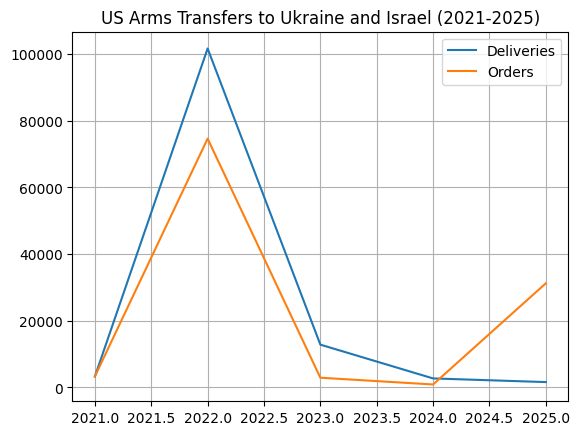

In [17]:
plt.plot(one.index, one, label = 'Deliveries')
plt.plot(two.index, two, label = 'Orders')
plt.grid(True)
plt.legend()

plt.title('US Arms Transfers to Ukraine and Israel (2021-2025)')

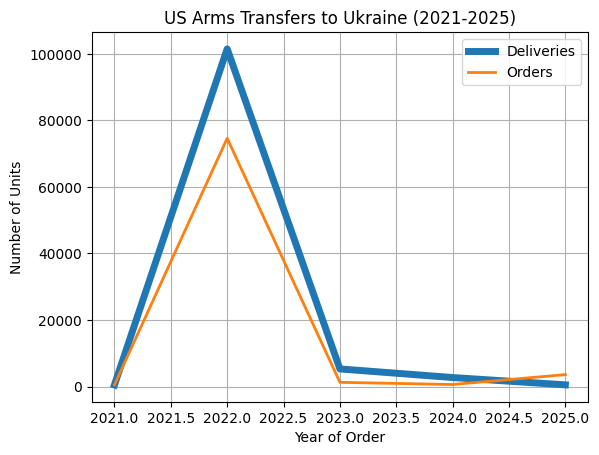

In [18]:

# Data for Ukraine
df_ukraine = df_filtered[df_filtered['Recipient'] == 'Ukraine']
ukraine_deliveries = df_ukraine.groupby('Year of Order')['Deliveries in the Year Range'].sum()
ukraine_orders = df_ukraine.groupby('Year of Order')['Number Ordered'].sum()

# Plot for Ukraine
plt.plot(ukraine_deliveries.index, ukraine_deliveries, label='Deliveries', linewidth = 5)
plt.plot(ukraine_orders.index, ukraine_orders, label='Orders', linewidth = 2)
plt.title('US Arms Transfers to Ukraine (2021-2025)')
plt.xlabel('Year of Order')
plt.ylabel('Number of Units')
plt.legend()
plt.grid(True)


As the threat of a full-scale invasion grew in late 2021, the Biden administration quietly accelerated these transfers. Between September 2021 and the February 2022 invasion, the U.S. sent multiple shipments containing shotguns, ammunition, and highly effective anti-aircraft and anti-armor systems like Stinger and Javelin missiles - Stimson Center, US Dept of War

(0.0, 100000.0)

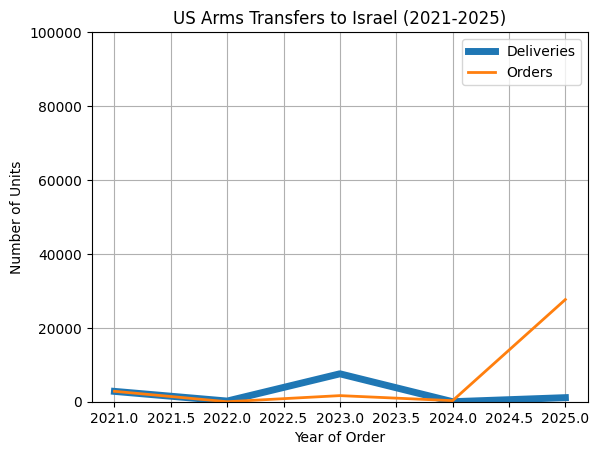

In [19]:
# Data for Israel
df_israel = df_filtered[df_filtered['Recipient'] == 'Israel']
israel_deliveries = df_israel.groupby('Year of Order')['Deliveries in the Year Range'].sum()
israel_orders = df_israel.groupby('Year of Order')['Number Ordered'].sum()

# Plot for Israel
plt.plot(israel_deliveries.index, israel_deliveries, label='Deliveries', linewidth = 5)
plt.plot(israel_orders.index, israel_orders, label='Orders', linewidth = 2)
plt.title('US Arms Transfers to Israel (2021-2025)')
plt.xlabel('Year of Order')
plt.ylabel('Number of Units')
plt.legend()
plt.grid(True)
plt.ylim(0, 100000)


# can continue experimenting with line width...

the US was regularly transferring lethal arms and military equipment to Israel before the October 7, 2023, Hamas attack. These transfers were part of a long-standing 10-year Memorandum of Understanding (MOU) signed in 2016, which provided Israel with roughly $3.8 billion in annual military assistance.Before October 2023, these routine US-supplied arsenals to the Israel Defense Forces (IDF) consisted primarily of advanced combat aircraft (such as F-15s, F-16s, and F-35s), transport and attack helicopters, precision-guided munitions, air defense interceptors for the Iron Dome, and various categories of ammunition. Additionally, the US maintained War Reserves Stock Allies-Israel—a stockpile of US-owned weapons located in Israel that is accessible to the IDF during emergencies. - Brown Uni

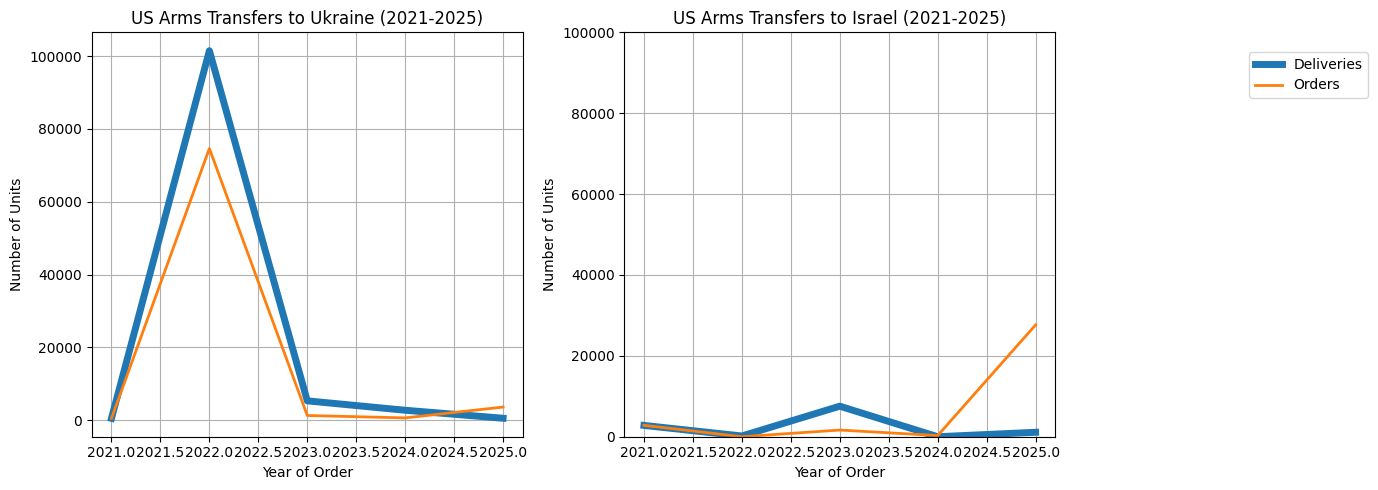

In [20]:
# format of above two plots if we put them next to each other using axes.set_ code

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

df_ukraine = df_filtered[df_filtered['Recipient'] == 'Ukraine']
ukraine_deliveries = df_ukraine.groupby('Year of Order')['Deliveries in the Year Range'].sum()
ukraine_orders = df_ukraine.groupby('Year of Order')['Number Ordered'].sum()

# Plot for Ukraine
axes[0].plot(ukraine_deliveries.index, ukraine_deliveries, label='Deliveries', linewidth = 5)
axes[0].plot(ukraine_orders.index, ukraine_orders, label='Orders', linewidth = 2)
axes[0].set_title('US Arms Transfers to Ukraine (2021-2025)')
axes[0].set_xlabel('Year of Order')
axes[0].set_ylabel('Number of Units')
axes[0].grid(True)

df_israel = df_filtered[df_filtered['Recipient'] == 'Israel']
israel_deliveries = df_israel.groupby('Year of Order')['Deliveries in the Year Range'].sum()
israel_orders = df_israel.groupby('Year of Order')['Number Ordered'].sum()

# Plot for Israel
axes[1].plot(israel_deliveries.index, israel_deliveries, label='Deliveries', linewidth = 5)
axes[1].plot(israel_orders.index, israel_orders, label='Orders', linewidth = 2)
axes[1].set_title('US Arms Transfers to Israel (2021-2025)')
axes[1].set_xlabel('Year of Order')
axes[1].set_ylabel('Number of Units')
axes[1].grid(True)
axes[1].set_ylim(0, 100000)

fig.legend(['Deliveries', 'Orders'], loc='upper right', bbox_to_anchor=(1.15, 0.9))
fig.tight_layout(rect=[0, 0, 0.9, 1])
fig.show()

In [21]:
df_filtered[df_filtered['Deliveries in the Year Range'] != df_filtered['Number Ordered']]
#Note: some entries may have number ordered>deliveries because the weapons are still being delivered and the database has not been updated with the new info
#(many entries are also missing values)

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
3467,Israel,United States,2025,2166.0,GBU-39 SDB,guided glide bomb,100.0,2025.0,New,0.02,43.32,2.00
3470,Israel,United States,2025,3000.0,AGM-114 Hellfire-2,anti-tank/air-to-surface missile,NaN,NaN,New,0.05,150.00,0.00
3471,Israel,United States,2025,17479.0,JDAM,guided bomb,1000.0,2025.0,New,0.02,349.58,20.00
3472,Israel,United States,2022,NaN,Terrier LT-79,armoured personnel carrier,NaN,NaN,New,0.14,0.00,0.00
3481,Israel,United States,2021,4.0,KC-46A Pegasus,tanker/transport aircraft,NaN,NaN,New,90.00,360.00,0.00
3623,Israel,United States,2024,25.0,APG-82,combat aircraft radar,NaN,NaN,New,2.50,62.50,0.00
3624,Israel,United States,2021,12.0,CH-53K King Stallion,transport helicopter,NaN,NaN,New,0.00,0.00,0.00
3682,Israel,United States,2025,5000.0,JDAM,guided bomb,NaN,NaN,New,0.02,100.00,0.00
3683,Israel,United States,2024,10.0,F-110,turbofan,NaN,NaN,New,3.25,32.50,0.00
3699,Israel,United States,2024,25.0,F-35A Lightning-2,fighter/ground-attack aircraft,NaN,NaN,New,55.00,1375.00,0.00


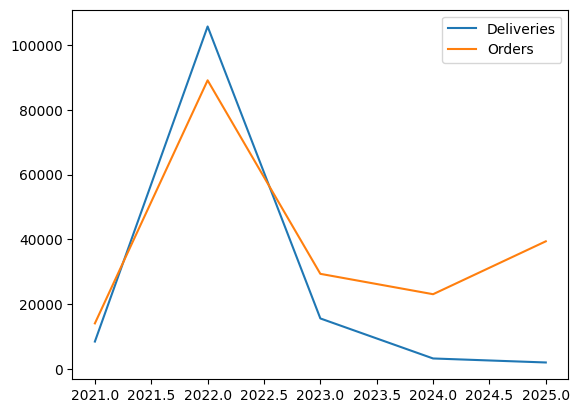

In [22]:
# looking at U.S supply to all countries and seeing distribution of number ordered v deliveries

df_US_five = df[(df['Supplier']=='United States') & (df['Year of Order'] >= 2021)]
df_US_five.groupby('Year of Order')['Deliveries in the Year Range']
df_US_five.groupby('Year of Order')['Number Ordered']
US_one = df_US_five.groupby('Year of Order')['Deliveries in the Year Range'].sum()
US_two = df_US_five.groupby('Year of Order')['Number Ordered'].sum()

plt.plot(US_one.index, US_one.values, label = 'Deliveries')
plt.plot(US_two.index, US_two.values, label = 'Orders')
plt.legend()
plt.show()

# note: this is for all recipients of US arms transfers, not just Ukraine and Israel (that was the first plot we made)
# we can attribute this similar variation compared to Ukraine and Israel with the fact that Ukraine and Israel received the most weapons from the US
# interesting difference around 2023-2024 though (there were proabably other countries ordering a lot of weapons and US supplied less...)

In [23]:
df_filtered['Weapon Description'].unique()

array(['guided glide bomb', 'anti-tank/air-to-surface missile',
       'guided bomb', 'armoured personnel carrier',
       'tanker/transport aircraft', 'combat aircraft radar',
       'transport helicopter', 'turbofan',
       'fighter/ground-attack aircraft', 'surface-to-air missile system',
       'surface-to-air missile', 'aircraft engine', 'multi-role radar',
       'one-way attack drone', 'anti-tank missile', 'air-search radar',
       'infantry fighting vehicle', 'portable surface-to-air missile',
       'artillery locating radar', 'self-propelled gun', 'towed gun',
       'tank', 'air-to-surface missile', 'patrol boat',
       'anti-ballistic missile missile',
       'mobile surface-to-air missile system', 'loitering munition',
       'guided rocket', 'armoured recovery vehicle',
       'short-range air-to-air missile', 'surface-to-surface missile',
       'multiple rocket launcher', 'mortar',
       'long-range air-to-air missile', 'vehicle engine',
       'anti-radar missile',

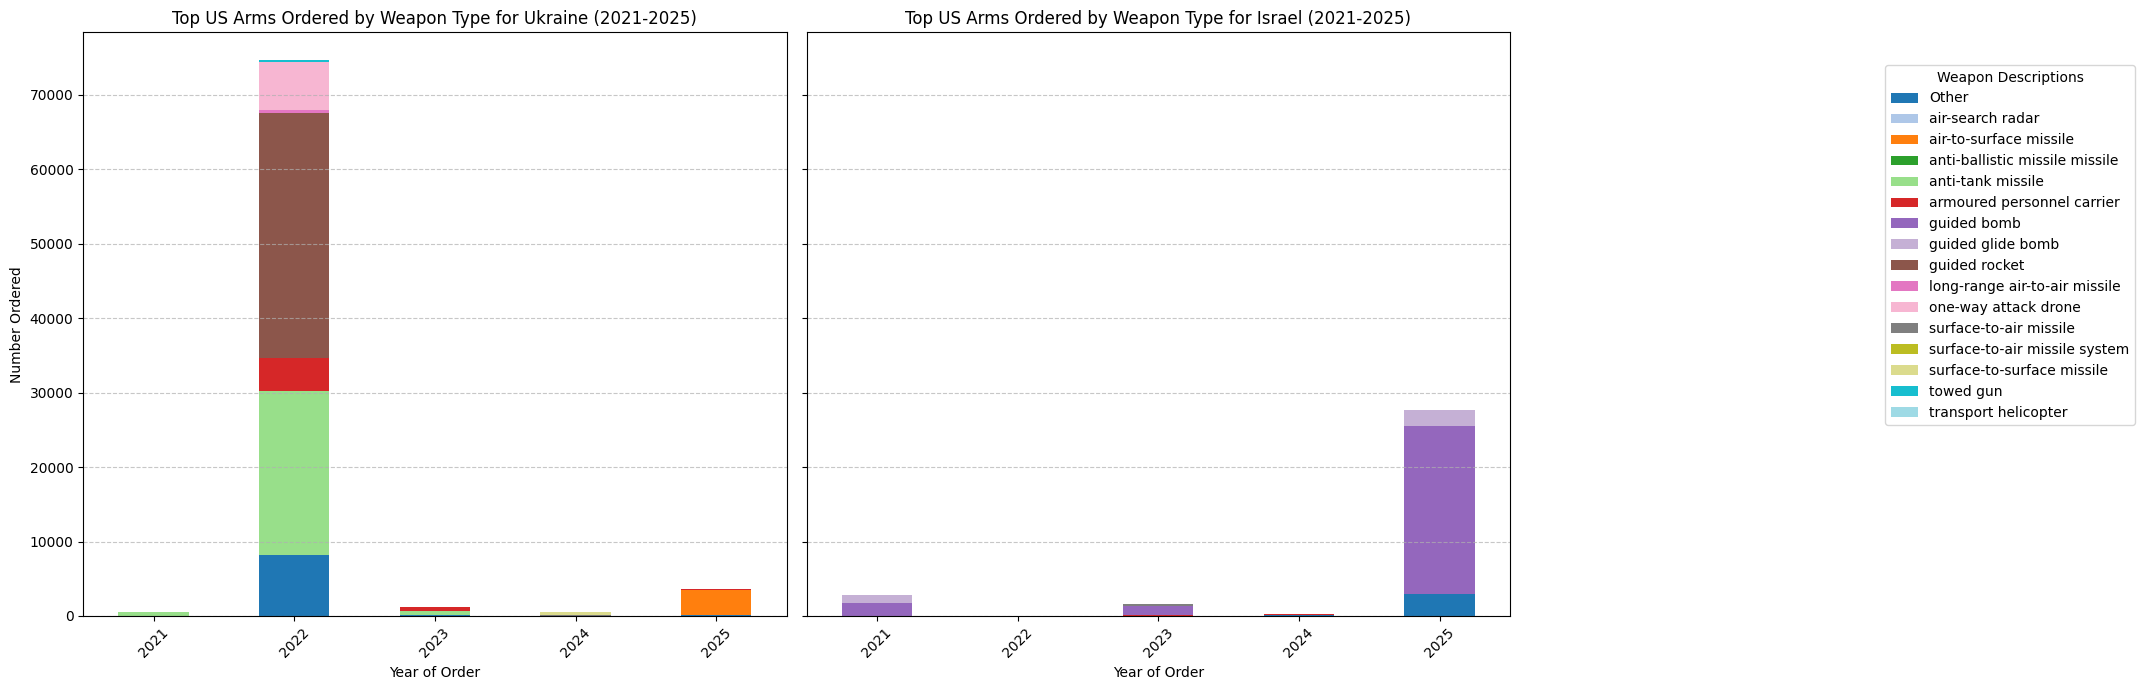

In [24]:
### lots of data vis ------------------>
# Defining weapon categorization
def get_weapon_category(description):
    description = str(description).lower()
    if 'aircraft' in description or 'helicopter' in description or 'turbofan' in description or 'radar' in description or 'patrol boat' in description:
        return 'Aircraft/Aircraft Systems'
    elif 'missile' in description or 'bomb' in description or 'rocket' in description or 'munition' in description or 'drone' in description or 'shell' in description or 'mortar' in description:
        return 'Missiles/Rockets/Ammunition'
    elif 'armoured' in description or 'tank' in description or 'gun' in description or 'vehicle' in description or 'bridgelayer' in description:
        return 'Armoured Vehicles/Artillery'
    else:
        return 'Other/Support'

# Applying categories
df_filtered['Weapon Category'] = df_filtered['Weapon Description'].apply(get_weapon_category)

all_weapon_counts = df_filtered['Weapon Description'].value_counts()
top_n = 15
top_n_weapons = all_weapon_counts.head(top_n).index.tolist()

def categorize_weapon(description, top_n_list):
    if description in top_n_list:
        return description
    return 'Other'

# Apply categorization for each country
df_ukraine_weapons = df_filtered[df_filtered['Recipient'] == 'Ukraine'].copy()
df_ukraine_weapons['Categorized Weapon'] = df_ukraine_weapons['Weapon Description'].apply(lambda x: categorize_weapon(x, top_n_weapons))

df_israel_weapons = df_filtered[df_filtered['Recipient'] == 'Israel'].copy()
df_israel_weapons['Categorized Weapon'] = df_israel_weapons['Weapon Description'].apply(lambda x: categorize_weapon(x, top_n_weapons))

# groupby!
ukraine_weapon_data_plot = df_ukraine_weapons.groupby(['Year of Order', 'Categorized Weapon'])['Number Ordered'].sum().unstack(fill_value=0)
israel_weapon_data_plot = df_israel_weapons.groupby(['Year of Order', 'Categorized Weapon'])['Number Ordered'].sum().unstack(fill_value=0)

# Include 'Other' and make sure all columns are in a consistent order for legend colors
all_legend_items = sorted(list(set(top_n_weapons + ['Other'])))

# include all possible legend items, filling with 0 if missing (NaN values that we added earlier in the notebook/earlier in the week)
# Note - make sure to include this in dataset/methodology section
for col in all_legend_items:
    if col not in ukraine_weapon_data_plot.columns:
        ukraine_weapon_data_plot[col] = 0
    if col not in israel_weapon_data_plot.columns:
        israel_weapon_data_plot[col] = 0

ukraine_weapon_data_plot = ukraine_weapon_data_plot[all_legend_items]
israel_weapon_data_plot = israel_weapon_data_plot[all_legend_items]

# subplots--->
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# plt/map color info --->
cmap = plt.get_cmap('tab20') # 'tab20' can handle up to 20 distinct colors (according to google...)
colors = [cmap(i) for i in np.linspace(0, 1, len(all_legend_items))]
color_dict = dict(zip(all_legend_items, colors))

# plot for Ukraine
ukraine_weapon_data_plot.plot(kind='bar', stacked=True, ax=axes[0],
                                 color=[color_dict[col] for col in ukraine_weapon_data_plot.columns])
axes[0].set_title('Top US Arms Ordered by Weapon Type for Ukraine (2021-2025)')
axes[0].set_xlabel('Year of Order')
axes[0].set_ylabel('Number Ordered')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].get_legend().remove()

# plot for Israel
israel_weapon_data_plot.plot(kind='bar', stacked=True, ax=axes[1],
                                color=[color_dict[col] for col in israel_weapon_data_plot.columns])
axes[1].set_title('Top US Arms Ordered by Weapon Type for Israel (2021-2025)')
axes[1].set_xlabel('Year of Order')
axes[1].set_ylabel('Number Ordered')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].get_legend().remove()

# can do separate plots but makes more sense when they are next to each other (that's why we use the axes.set_ and not the plt.)

# lengend --->
legend_patches = [plt.Rectangle((0,0),1,1, fc=color_dict[label]) for label in all_legend_items]
fig.legend(legend_patches, all_legend_items, title='Weapon Descriptions',
           bbox_to_anchor=(1.05, 0.9), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [25]:
## Confirming info in plots above

print("Total 'Number Ordered' by Categorized Weapon for Ukraine:")
print(df_ukraine_weapons.groupby('Categorized Weapon')['Number Ordered'].sum())

print("\nTotal 'Number Ordered' by Categorized Weapon for Israel:")
print(df_israel_weapons.groupby('Categorized Weapon')['Number Ordered'].sum())

Total 'Number Ordered' by Categorized Weapon for Ukraine:
Categorized Weapon
Other                              8427.0
air-search radar                     25.0
air-to-surface missile             3350.0
anti-ballistic missile missile        0.0
anti-tank missile                 23080.0
armoured personnel carrier         5063.0
guided glide bomb                     0.0
guided rocket                     32900.0
long-range air-to-air missile       325.0
one-way attack drone               6520.0
surface-to-air missile               90.0
surface-to-air missile system        14.0
surface-to-surface missile          500.0
towed gun                           255.0
transport helicopter                 23.0
Name: Number Ordered, dtype: float64

Total 'Number Ordered' by Categorized Weapon for Israel:
Categorized Weapon
Other                             3095.0
armoured personnel carrier         350.0
guided bomb                      25479.0
guided glide bomb                 3166.0
surface-to-air 

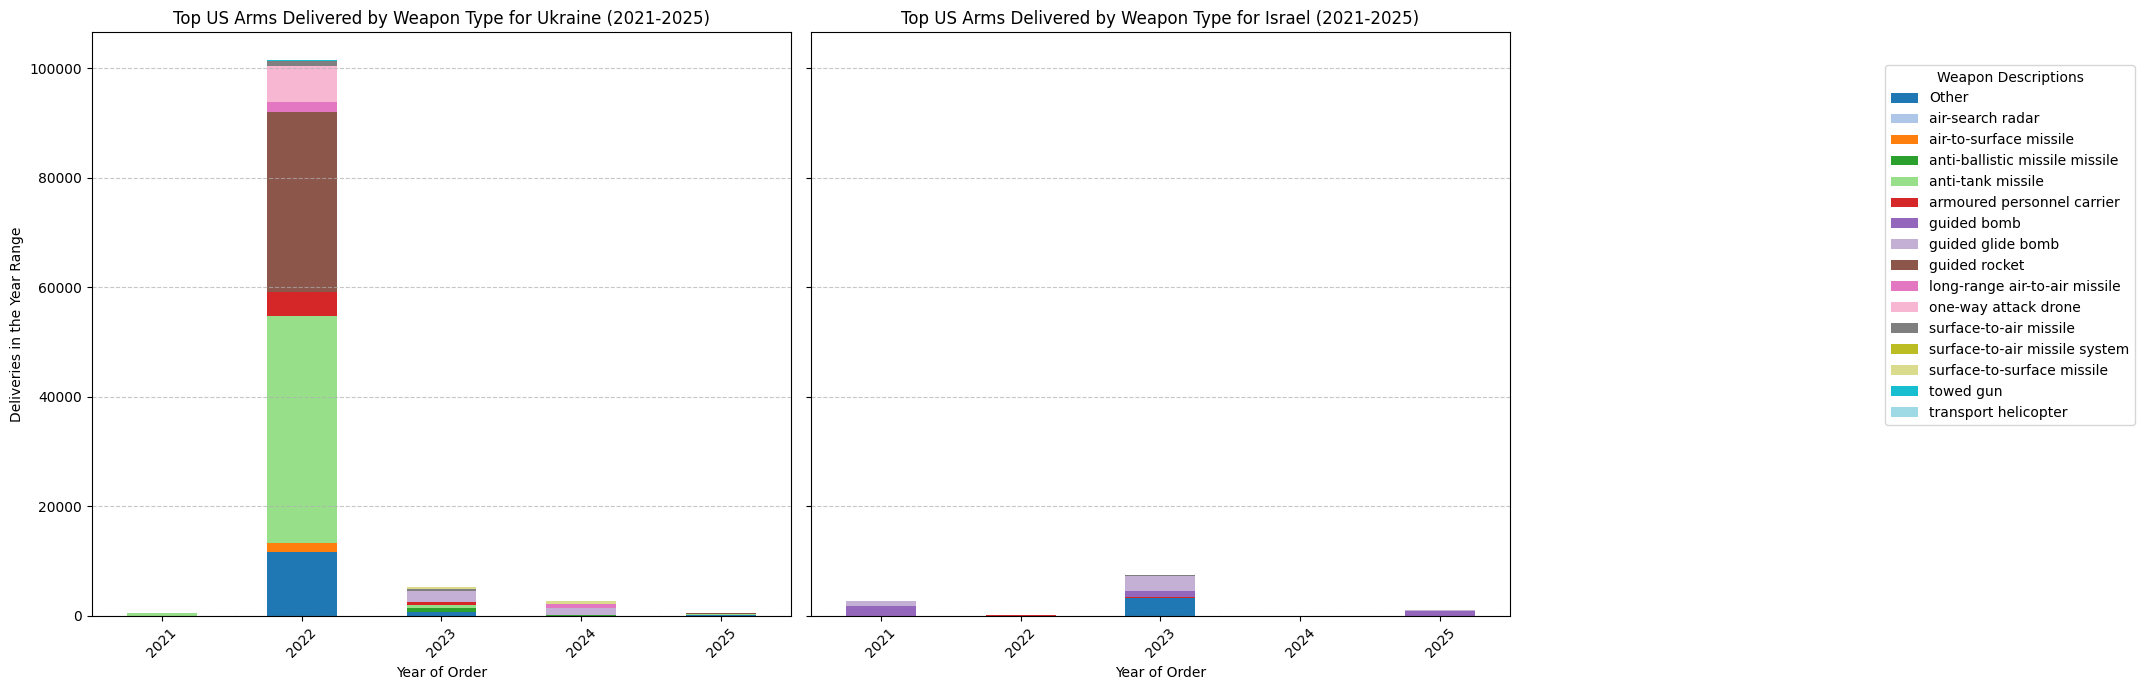

In [26]:
# Defining weapon categorization
def get_weapon_category(description):
    description = str(description).lower()
    if 'aircraft' in description or 'helicopter' in description or 'turbofan' in description or 'radar' in description or 'patrol boat' in description:
        return 'Aircraft/Aircraft Systems'
    elif 'missile' in description or 'bomb' in description or 'rocket' in description or 'munition' in description or 'drone' in description or 'shell' in description or 'mortar' in description:
        return 'Missiles/Rockets/Ammunition'
    elif 'armoured' in description or 'tank' in description or 'gun' in description or 'vehicle' in description or 'bridgelayer' in description:
        return 'Armoured Vehicles/Artillery'
    else:
        return 'Other/Support'


df_filtered['Weapon Category'] = df_filtered['Weapon Description'].apply(get_weapon_category)


all_weapon_counts = df_filtered['Weapon Description'].value_counts()
top_n = 15
top_n_weapons = all_weapon_counts.head(top_n).index.tolist()


def categorize_weapon(description, top_n_list):
    if description in top_n_list:
        return description
    return 'Other'

# Apply categorization for each country
df_ukraine_weapons = df_filtered[df_filtered['Recipient'] == 'Ukraine'].copy()
df_ukraine_weapons['Categorized Weapon'] = df_ukraine_weapons['Weapon Description'].apply(lambda x: categorize_weapon(x, top_n_weapons))

df_israel_weapons = df_filtered[df_filtered['Recipient'] == 'Israel'].copy()
df_israel_weapons['Categorized Weapon'] = df_israel_weapons['Weapon Description'].apply(lambda x: categorize_weapon(x, top_n_weapons))

# groupby! -- but we're doing deliveries not order!!
ukraine_weapon_data_plot = df_ukraine_weapons.groupby(['Year of Order', 'Categorized Weapon'])['Deliveries in the Year Range'].sum().unstack(fill_value=0)
israel_weapon_data_plot = df_israel_weapons.groupby(['Year of Order', 'Categorized Weapon'])['Deliveries in the Year Range'].sum().unstack(fill_value=0)

# Include 'Other' and make sure all columns are in a consistent order for legend colors
all_legend_items = sorted(list(set(top_n_weapons + ['Other'])))

# include all possible legend items, filling with 0 if missing (NaN values that we added earlier in the notebook/earlier in the week)
# Note - make sure to include this in dataset/methodology section
for col in all_legend_items:
    if col not in ukraine_weapon_data_plot.columns:
        ukraine_weapon_data_plot[col] = 0
    if col not in israel_weapon_data_plot.columns:
        israel_weapon_data_plot[col] = 0

ukraine_weapon_data_plot = ukraine_weapon_data_plot[all_legend_items]
israel_weapon_data_plot = israel_weapon_data_plot[all_legend_items]

# subplots--->
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# plt/map color info --->
cmap = plt.get_cmap('tab20') # 'tab20' can handle up to 20 distinct colors (according to google...)
colors = [cmap(i) for i in np.linspace(0, 1, len(all_legend_items))]
color_dict = dict(zip(all_legend_items, colors))

# plot for Ukraine
ukraine_weapon_data_plot.plot(kind='bar', stacked=True, ax=axes[0],
                                 color=[color_dict[col] for col in ukraine_weapon_data_plot.columns])
axes[0].set_title('Top US Arms Delivered by Weapon Type for Ukraine (2021-2025)')
axes[0].set_xlabel('Year of Order')
axes[0].set_ylabel('Deliveries in the Year Range')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].get_legend().remove()

# plot for Israel
israel_weapon_data_plot.plot(kind='bar', stacked=True, ax=axes[1],
                                color=[color_dict[col] for col in israel_weapon_data_plot.columns])
axes[1].set_title('Top US Arms Delivered by Weapon Type for Israel (2021-2025)')
axes[1].set_xlabel('Year of Order')
axes[1].set_ylabel('Deliveries in the Year Range')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].get_legend().remove()

# lengend --->
legend_patches = [plt.Rectangle((0,0),1,1, fc=color_dict[label]) for label in all_legend_items]
fig.legend(legend_patches, all_legend_items, title='Weapon Descriptions',
           bbox_to_anchor=(1.05, 0.9), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# good to show this plot next to the plot showing the Number Ordered -- there are differences

In [27]:
## Confirming this info to --->

print("Total 'Deliveries in the Year Range' by Categorized Weapon for Ukraine:")
print(df_ukraine_weapons.groupby('Categorized Weapon')['Deliveries in the Year Range'].sum())

print("\nTotal 'Deliveries in the Year Range' by Categorized Weapon for Israel:")
print(df_israel_weapons.groupby('Categorized Weapon')['Deliveries in the Year Range'].sum())

Total 'Deliveries in the Year Range' by Categorized Weapon for Ukraine:
Categorized Weapon
Other                             12654.0
air-search radar                     17.0
air-to-surface missile             1550.0
anti-ballistic missile missile      850.0
anti-tank missile                 42680.0
armoured personnel carrier         4933.0
guided glide bomb                  3250.0
guided rocket                     33100.0
long-range air-to-air missile      2575.0
one-way attack drone               6520.0
surface-to-air missile             1215.0
surface-to-air missile system        11.0
surface-to-surface missile          850.0
towed gun                           255.0
transport helicopter                 23.0
Name: Deliveries in the Year Range, dtype: float64

Total 'Deliveries in the Year Range' by Categorized Weapon for Israel:
Categorized Weapon
Other                            3300.0
armoured personnel carrier        329.0
guided bomb                      4000.0
guided glide bomb

In [28]:
df_filtered['Status'].value_counts()

# ok so no 'second hand but modernized' label (We saw this a few times in the csv file/OG df)

,count
Status,
Second hand,58
New,54


In [29]:
df['Status'].value_counts()

# ok there weren't that many in the OG df anyway

,count
Status,
New,6995
Second hand,2594
Second hand but modernized,150


In [30]:
df_filtered['Status']

,Status
3467,New
3470,New
3471,New
3472,New
3481,New
...,...
8904,New
8905,Second hand
8906,Second hand
8907,New


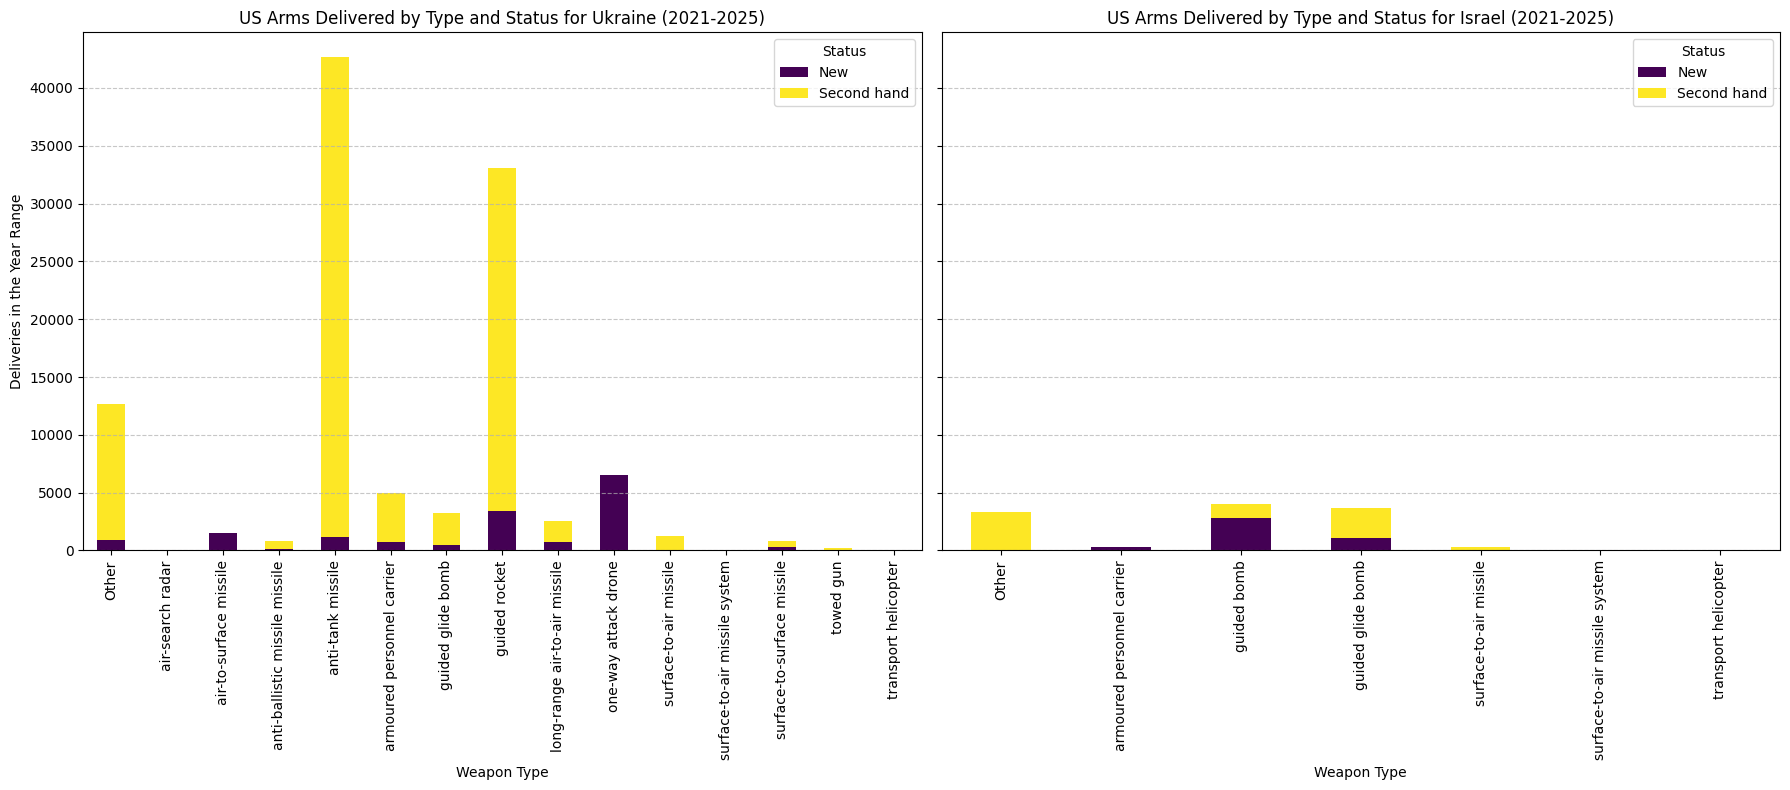

In [31]:

# Group by Categorized Weapon and Status, then sum 'Number Ordered'
ukraine_status_data = df_ukraine_weapons.groupby(['Categorized Weapon', 'Status'])['Deliveries in the Year Range'].sum().unstack(fill_value=0)
israel_status_data = df_israel_weapons.groupby(['Categorized Weapon', 'Status'])['Deliveries in the Year Range'].sum().unstack(fill_value=0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Plot for Ukraine
ukraine_status_data.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('US Arms Delivered by Type and Status for Ukraine (2021-2025)')
axes[0].set_xlabel('Weapon Type')
axes[0].set_ylabel('Deliveries in the Year Range')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title='Status')


# Plot for Israel
israel_status_data.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('US Arms Delivered by Type and Status for Israel (2021-2025)')
axes[1].set_xlabel('Weapon Type')
axes[1].set_ylabel('Deliveries in the Year Range')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

# initially had 'Number Ordered' but this didn't make sense - and it gave double the amount of weapons count for Israel which was false info!
# change to deliveries in the year range because countries aren't specifying/don't choose weapon status when ordering them

# Plot Analysis:
# Ukraine get's a lot of second hand - but they are also getting a lot more weapons
# important that Ukraine is getting lots of new one-way attack drones --> many articles talking about drone warfare/how Ukraine drones are being used a lot
# Israel getting a lot of new guided bombs --> can explore how these weapons reflect the nature of the conflict (or how nature of the conflict leads us to these weapons)

In [32]:
## last things before t-tests: finding difference in total weapons ordered and delivered
## for differences regarding specific weapons -- can use confirming print statements above

print ('Total Weapons Ordered by Ukraine:', df_ukraine_weapons['Number Ordered'].sum())
print ('Total Weapons Ordered by Israel:', df_israel_weapons['Number Ordered'].sum())

print ('Total Weapons Delivered to Ukraine:', df_ukraine_weapons['Deliveries in the Year Range'].sum())
print ('Total Weapons Delivered to Israel:', df_israel_weapons['Deliveries in the Year Range'].sum())

# remember all of this is when the US is the supplier and it's between the years 2021-2025 (max year of dataset)
# can use these numbers for exact data comparisons...

Total Weapons Ordered by Ukraine: 80572.0
Total Weapons Ordered by Israel: 32404.0
Total Weapons Delivered to Ukraine: 110483.0
Total Weapons Delivered to Israel: 11631.0


T-Test / Finding Statistical Significance....

- *comparing Ukraine Deliveries and Israel Deliveries*
- *comparing number of unique weapons for Ukraine vs. Israel*
- *comparing Ukraine count of new vs. Isreal count of new*
- *comparing Ukraine count of second hand vs. Isreal count of second hand*

- can we compare number ordered to number delivered for each country -- can also just use data visual for this

These are all numerical...

** so will proabably be running 2 sample t-test - measures whether the mean of one group differs from the mean of another group **

- could do paired 2 sample test if we want to look at across time...but five years isn't that long ... and we could just look at data plots

In [33]:
!pip install scipy
import scipy.stats as stats

In [34]:
# t_stat, p_val = stats.ttest_ind(group1,group2)
# t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "less")

# Day 5-6

here we're revieweing our null values in the filtered and in the original dataset(before we changed null to NaN) because to run the ttest we have to drop any null / na values

- this is good to come back to for exact missing data numbers and limitations in data analysis

- all the data reflected by the data visuals and ttest is the same (they both just skip / omit the missing values in different ways)



In [35]:
df_filtered.isna().sum()

,0
Recipient,0
Supplier,0
Year of Order,0
Number Ordered,28
Weapon Designation,0
Weapon Description,0
Deliveries in the Year Range,17
Year(s) of delivery,64
Status,0
SIPRI TIV per unit,0


In [36]:
# Null values in the original DataFrame before filtering
print('NaN counts in original df:')
print(df.isna().sum())

NaN counts in original df:
Recipient                            0
Supplier                             0
Year of Order                        0
Number Ordered                      85
Weapon Designation                   0
Weapon Description                   0
Deliveries in the Year Range       422
Year(s) of delivery               4830
Status                               0
SIPRI TIV per unit                   0
SIPRI TIV for total order            0
SIPRI TIV of delivered weapons       0
dtype: int64


In [37]:
groups = df_filtered.groupby('Recipient')['Deliveries in the Year Range']
group1 = groups.get_group('Ukraine').dropna()
group2 = groups.get_group('Israel').dropna()

In [38]:
t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "greater")

In [39]:
result = t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "greater")

In [40]:
test_statistic = result.statistic

In [41]:
p_val = result.pvalue

In [42]:
print(test_statistic, p_val)

0.2734450282562569 0.3925587455031993


In [43]:
print('Standard deviation of Ukraine deliveries:', group1.std())
print('Standard deviation of Israel deliveries:', group2.std())

Standard deviation of Ukraine deliveries: 4545.696564180209
Standard deviation of Israel deliveries: 1095.4429676868374


This two-sample independent t-test above (with alternative='greater') was performed to see if the average 'Deliveries in the Year Range' to Ukraine is greater than that to Israel.

because p_val (0.392) > our threshold of significance (0.05) we fail to reject the null hypothesis.

t-test did not give statistically significant results

In [44]:
## next t-test ---->


groups = df_filtered.groupby('Recipient')['Number Ordered']
group1 = groups.get_group('Ukraine').dropna()
group2 = groups.get_group('Israel').dropna()

In [45]:
t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "less")
result = t_stat, p_val = stats.ttest_ind(group1, group2, alternative = "less")
test_statistic = result.statistic
p_val = result.pvalue

In [46]:
print(test_statistic, p_val)

-0.31515071447906257 0.37672391299024127


In [47]:
print('Standard deviation of Ukraine orders:', group1.std())
print('Standard deviation of Israel orders:', group2.std())

Standard deviation of Ukraine orders: 4619.484348585391
Standard deviation of Israel orders: 3957.201597620537


fail to reject null hypothesis for above t-test

In [48]:
## next tests will be chi sqaure for weapons and status comparison


con_table = pd.crosstab(
        df_filtered["Recipient"], df_filtered["Weapon Description"])

In [49]:
result = stats.chi2_contingency(con_table)

In [50]:
chi2_stat = result.statistic
p_val = result.pvalue

In [51]:
expected_table = result.expected_freq

In [52]:
print(chi2_stat)
print(p_val)
print(expected_table)

66.18586612576064
0.005713869691003802
[[ 0.66964286  0.66964286  0.22321429  0.66964286  0.22321429  1.33928571
   0.44642857  0.22321429  0.22321429  3.79464286  0.22321429  0.22321429
   0.44642857  0.22321429  0.44642857  0.89285714  1.5625      0.66964286
   0.22321429  0.44642857  0.44642857  1.33928571  0.44642857  0.22321429
   0.44642857  0.44642857  0.89285714  0.22321429  0.22321429  0.22321429
   0.22321429  0.22321429  1.11607143  1.33928571  0.66964286  0.22321429
   0.44642857  0.66964286  0.66964286  0.22321429  0.44642857]
 [ 2.33035714  2.33035714  0.77678571  2.33035714  0.77678571  4.66071429
   1.55357143  0.77678571  0.77678571 13.20535714  0.77678571  0.77678571
   1.55357143  0.77678571  1.55357143  3.10714286  5.4375      2.33035714
   0.77678571  1.55357143  1.55357143  4.66071429  1.55357143  0.77678571
   1.55357143  1.55357143  3.10714286  0.77678571  0.77678571  0.77678571
   0.77678571  0.77678571  3.88392857  4.66071429  2.33035714  0.77678571
   1.55357

We reject the null hypothesis in the chi square above!

This means that there is a statistical significance when we compare the weapon description between ukraine and israel

In [53]:
## next chi square---->

con_table = pd.crosstab(
        df_filtered["Recipient"], df_filtered["Status"])

In [54]:
result = stats.chi2_contingency(con_table)

In [55]:
chi2_stat = result.statistic
p_val = result.pvalue

In [56]:
expected_table = result.expected_freq

In [57]:
print(chi2_stat)
print(p_val)
print(expected_table)

11.435867353679479
0.0007203983855544699
[[12.05357143 12.94642857]
 [41.94642857 45.05357143]]


p_val<0.05 so We reject the null hypothesis in the chi square above!

This means that there is a statistical significance when we compare the weapon status(new v secondhand) between ukraine and israel

next steps:

- double check t-test work above..
- prep for lightning talk on Monday
- continue lit review / save sources
- brainstorm potential classification/predictive models
  - maybe use feature importance tool to confirm significance of weapon description and status columns???




# Day 7-8-9

In [58]:
## check data points for df_ukraine and df_israel
## low data points could explain why first couple graphs had very smooth lines

df_ukraine.info()
## 87 entries...
df_israel.info()
## 25 entries...

## this could go in limitations section? - or just use to explain graphics in more detail
## we've talked about how limited datapoints in dataset is a big thing to mention throughout

<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 8816 to 8908
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       87 non-null     object 
 1   Supplier                        87 non-null     object 
 2   Year of Order                   87 non-null     int64  
 3   Number Ordered                  64 non-null     float64
 4   Weapon Designation              87 non-null     object 
 5   Weapon Description              87 non-null     object 
 6   Deliveries in the Year Range    83 non-null     float64
 7   Year(s) of delivery             39 non-null     float64
 8   Status                          87 non-null     object 
 9   SIPRI TIV per unit              87 non-null     float64
 10  SIPRI TIV for total order       87 non-null     float64
 11  SIPRI TIV of delivered weapons  87 non-null     float64
dtypes: float64(6), int64(1), object(5)
mem

t-test important info:

- Even though the raw data (the sample means) shows a difference, the statistical test indicates that this difference is not large enough or consistent enough relative to the variance in the data to rule out chance.

data important info:

- Delivery Lag: SIPRI data records deliveries. A major policy change in Washington might take 1–3 years to manifest in your data. Mention this in final paper as a "delivery lag" caveat.

In [59]:
## lets look at the means for each filtered down df

print ('Ukraine:', df_ukraine['Deliveries in the Year Range'].mean())
print('Israel:', df_israel['Deliveries in the Year Range'].mean())

Ukraine: 1331.120481927711
Israel: 969.25


In [60]:
## and with orders

print ('Ukraine:', df_ukraine['Number Ordered'].mean())
print('Israel:', df_israel['Number Ordered'].mean())

Ukraine: 1258.9375
Israel: 1620.2


In [61]:
## note: these means can help us to determine whether to put 'greater' or 'less' in alternative section of t-test (?)

training KNN classifying --> (mostly to just confirm significance of features in significant t-tests)

In [62]:
!pip install scikit-learn

import sklearn

from sklearn.model_selection import train_test_split

from sklearn.metrics import *

In [63]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112 entries, 3467 to 8908
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       112 non-null    object 
 1   Supplier                        112 non-null    object 
 2   Year of Order                   112 non-null    int64  
 3   Number Ordered                  84 non-null     float64
 4   Weapon Designation              112 non-null    object 
 5   Weapon Description              112 non-null    object 
 6   Deliveries in the Year Range    95 non-null     float64
 7   Year(s) of delivery             48 non-null     float64
 8   Status                          112 non-null    object 
 9   SIPRI TIV per unit              112 non-null    float64
 10  SIPRI TIV for total order       112 non-null    float64
 11  SIPRI TIV of delivered weapons  112 non-null    float64
 12  Weapon Category                 112 n

In [64]:
from sklearn.preprocessing import OneHotEncoder


features_categorical = df_filtered[['Weapon Description', 'Status']]

labels = df_filtered['Recipient']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
features_encoded = encoder.fit_transform(features_categorical)

features = pd.DataFrame(features_encoded, columns=encoder.get_feature_names_out(features_categorical.columns), index=df_filtered.index)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state = 42)

In [66]:
from sklearn.neighbors import KNeighborsClassifier

In [67]:
model = KNeighborsClassifier(n_neighbors=2)

In [68]:
model.fit(X_train, y_train)
pred = model.predict(X_test)

0.9130434782608695


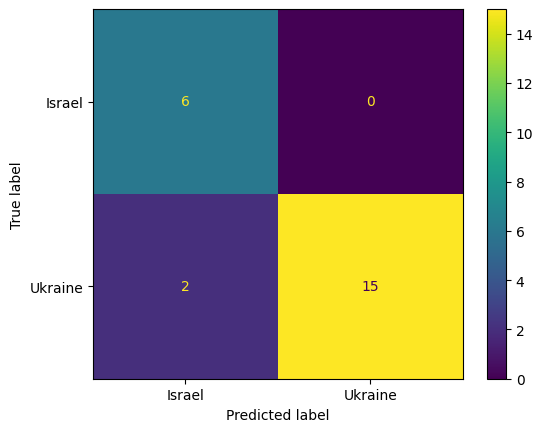

In [69]:
import sklearn.metrics as metrics

accuracy = metrics.accuracy_score(y_test, pred)
print (accuracy)
metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred)

plt.show()

In [70]:
# Prediction/accuracy for training --> compare with test acc. --> check for overfitting this way (?)
pred_train = model.predict(X_train)


accuracy_train = metrics.accuracy_score(y_train, pred_train)

print('Training Accuracy:', accuracy_train)
print('Testing Accuracy:', accuracy)

# overfitting......??
# testing > training

Training Accuracy: 0.8876404494382022
Testing Accuracy: 0.9130434782608695


In [71]:
df_filtered['Weapon Description'].unique()

array(['guided glide bomb', 'anti-tank/air-to-surface missile',
       'guided bomb', 'armoured personnel carrier',
       'tanker/transport aircraft', 'combat aircraft radar',
       'transport helicopter', 'turbofan',
       'fighter/ground-attack aircraft', 'surface-to-air missile system',
       'surface-to-air missile', 'aircraft engine', 'multi-role radar',
       'one-way attack drone', 'anti-tank missile', 'air-search radar',
       'infantry fighting vehicle', 'portable surface-to-air missile',
       'artillery locating radar', 'self-propelled gun', 'towed gun',
       'tank', 'air-to-surface missile', 'patrol boat',
       'anti-ballistic missile missile',
       'mobile surface-to-air missile system', 'loitering munition',
       'guided rocket', 'armoured recovery vehicle',
       'short-range air-to-air missile', 'surface-to-surface missile',
       'multiple rocket launcher', 'mortar',
       'long-range air-to-air missile', 'vehicle engine',
       'anti-radar missile',

In [72]:
### using the model:

new_data = pd.DataFrame([['long-range air-to-air missile', 'New']], columns=['Weapon Description', 'Status'])

# Using encoder from before to one hot encode new_data
new_data_encoded = encoder.transform(new_data)


new_features_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(new_data.columns))
new_prediction = model.predict(new_features_df)

print("New data for prediction:", new_data)

print("\nPredicted Recipient:", new_prediction)

New data for prediction:               Weapon Description Status
0  long-range air-to-air missile    New

Predicted Recipient: ['Ukraine']


In [73]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, features, labels, cv=5) # Using 5-fold cross-validation

print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())
print("Standard deviation of cross-validation scores:", cv_scores.std())

## significant drop in scores (training acc = 88% but cv score in 40%)
## suggests overfitting/model does not generalize well to new data

Cross-validation scores: [0.39130435 0.34782609 0.45454545 0.5        0.31818182]
Mean cross-validation score: 0.4023715415019763
Standard deviation of cross-validation scores: 0.06699109196172792


In [74]:
## to improve KNN generalization/reduce overfitting:
  # can tune n_neighbors (high, odd number)
  # use more data (this will be hard though) (df_filtered has 112 entries according to info above)
  # choose one major feature to train model on
  # can try other models like Random Forest Classifier

In [75]:
model_two = KNeighborsClassifier(n_neighbors=3)

In [76]:
model_two.fit(X_train, y_train)
pred = model_two.predict(X_test)

0.8695652173913043


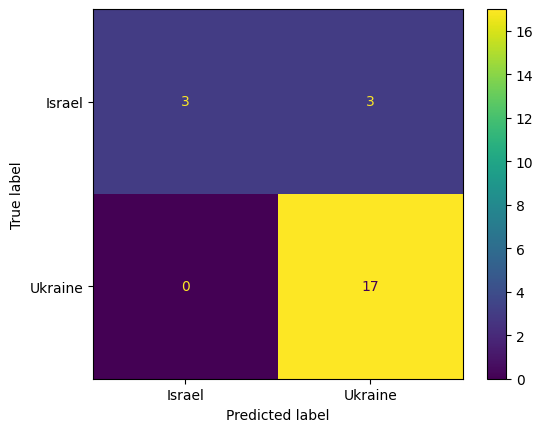

In [77]:

accuracy = metrics.accuracy_score(y_test, pred)
print (accuracy)
metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred)

plt.show()

In [78]:
cv_scores = cross_val_score(model_two, features, labels, cv=5) # Using 5-fold cross-validation

print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())
print("Standard deviation of cross-validation scores:", cv_scores.std())

# cv scores went up a little bit

## can try to use random forest classifier to get a better generalizing model

Cross-validation scores: [0.43478261 0.43478261 0.54545455 0.54545455 0.31818182]
Mean cross-validation score: 0.45573122529644267
Standard deviation of cross-validation scores: 0.08473261099829905


# **Note: New Model: Random Forest Classifier ---->**

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_features_to_encode = df_filtered[['Weapon Description', 'Status']]
y = df_filtered['Recipient']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X_features_to_encode)
X = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(X_features_to_encode.columns), index=df_filtered.index)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(random_state=42) # there are some other parameters for this too... but we don't have to do that lowkey..
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
accuracy_rf = metrics.accuracy_score(y_test, y_pred)
print (accuracy_rf)

0.8260869565217391


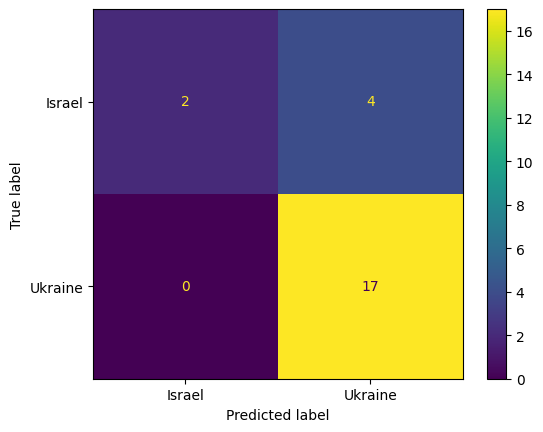

In [80]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

## realize that there are more datapoints for Ukraine so makes sense that model classifies Ukraine correctly more

## interesting that there is no instance where model predicts Israel when it's actually Ukraine

## maybe ask for interpreting help with confusion matrices

In [89]:
# Day 8 - calculate some more metrics (precision, recall, F1)

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred, pos_label='Ukraine')
recall = recall_score(y_test, y_pred, pos_label='Ukraine')
f1 = f1_score(y_test, y_pred, pos_label='Ukraine')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}\n")

print("Comprehensive Report:")
print(classification_report(y_test, y_pred))

## maybe some overfitting here too with 1.00 values below...

Precision: 0.8095
Recall:    1.0000
F1 Score:  0.8947

Comprehensive Report:
              precision    recall  f1-score   support

      Israel       1.00      0.33      0.50         6
     Ukraine       0.81      1.00      0.89        17

    accuracy                           0.83        23
   macro avg       0.90      0.67      0.70        23
weighted avg       0.86      0.83      0.79        23



important findings:

Precision (Ukraine): 0.8095 (80.95%) - When the model predicts 'Ukraine', it is correct about 81% of the time.
Recall (Ukraine): 1.0000 (100%) - The model correctly identifies all actual 'Ukraine' instances.
F1 Score (Ukraine): 0.8947 (89.47%) - This is the harmonic mean of precision and recall for 'Ukraine', indicating a strong balance between the two.
Looking at the comprehensive report:

Israel: The model has perfect precision (1.00) when predicting 'Israel', meaning every time it predicted 'Israel', it was correct. However, its recall is low (0.33), indicating it missed a significant number of actual 'Israel' cases (it only identified 33% of them).
Ukraine: The model effectively identifies all 'Ukraine' cases (recall 1.00) but has a slightly lower precision, meaning it sometimes incorrectly classifies 'Israel' as 'Ukraine'.
These metrics highlight the model's bias towards predicting 'Ukraine', which makes sense given that there are more 'Ukraine' data points in the test set (17 vs. 6 for Israel), leading to high recall for Ukraine but lower recall for Israel.

In [82]:
y_pred_train = rf_model.predict(X_train)


accuracy_train = metrics.accuracy_score(y_train, y_pred_train)

print('Training Accuracy:', accuracy_train)
print('Testing Accuracy:', accuracy_rf)

## more expected results
# makes sense that testing would be slightly lower than training -- this means model is working correctly...

Training Accuracy: 0.9101123595505618
Testing Accuracy: 0.8260869565217391


In [83]:
cv_scores = cross_val_score(rf_model, features, labels, cv=5) # Using 5-fold cross-validation

print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())
print("Standard deviation of cross-validation scores:", cv_scores.std())

## these are much better cv scores ---->
## model is less prone to overfitting than KNN ---> scores prove model is not being overfitted...

Cross-validation scores: [0.91304348 0.86956522 0.81818182 0.81818182 0.68181818]
Mean cross-validation score: 0.8201581027667985
Standard deviation of cross-validation scores: 0.07773609340040803


In [84]:
### using the Random Forest model:

new_data = pd.DataFrame([['long-range air-to-air missile', 'New']], columns=['Weapon Description', 'Status'])

# Using encoder from before to one hot encode new_data
new_data_encoded = encoder.transform(new_data)


new_features_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(new_data.columns))
new_prediction = rf_model.predict(new_features_df)

print("New data for prediction:", new_data)

print("\nPredicted Recipient:", new_prediction)

New data for prediction:               Weapon Description Status
0  long-range air-to-air missile    New

Predicted Recipient: ['Ukraine']


In [85]:
importances = rf_model.feature_importances_
for X_col, importance in zip(X.columns, importances):
    print(X_col,':', importance)

# could maybe be useful for some analysis
  # though feature importance coefficients aren't that high
  # can cross compare the highest coefficients with the visual though and see if they can confirm same trends/findings...

Weapon Description_air-search radar : 0.010042935594483104
Weapon Description_air-to-surface missile : 0.008371893509699371
Weapon Description_aircraft engine : 0.052801960248687614
Weapon Description_anti-ballistic missile missile : 0.006152006448463242
Weapon Description_anti-radar missile : 0.000475373677678726
Weapon Description_anti-tank missile : 0.019089868998332392
Weapon Description_anti-tank/air-to-surface missile : 0.12190923321016493
Weapon Description_armoured bridgelayer : 0.00038402513788103626
Weapon Description_armoured engineer vehicle : 0.0007173065674249728
Weapon Description_armoured personnel carrier : 0.07057385735160988
Weapon Description_armoured recovery vehicle : 0.0008024715950764396
Weapon Description_armoured supply vehicle : 0.0008634131834938423
Weapon Description_artillery locating radar : 0.0006473894189012863
Weapon Description_combat aircraft radar : 0.04480389104754953
Weapon Description_fighter/ground-attack aircraft : 0.06184810990060699
Weapon De

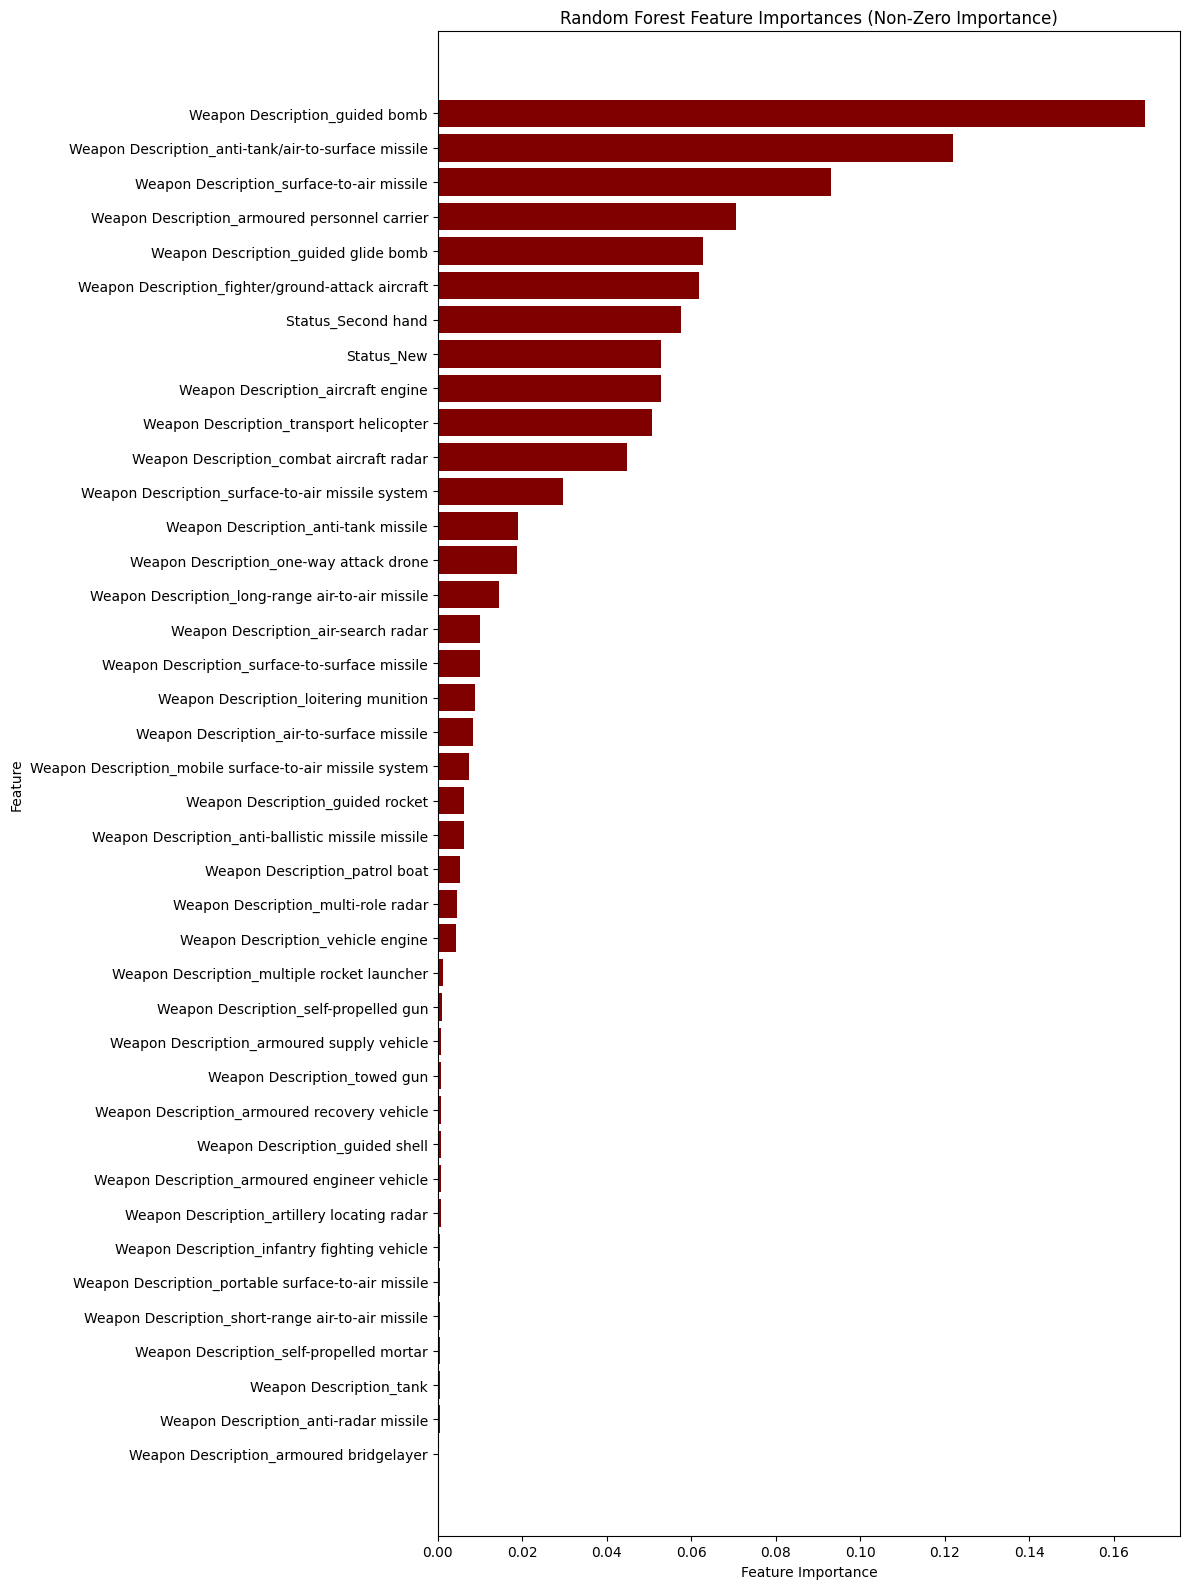

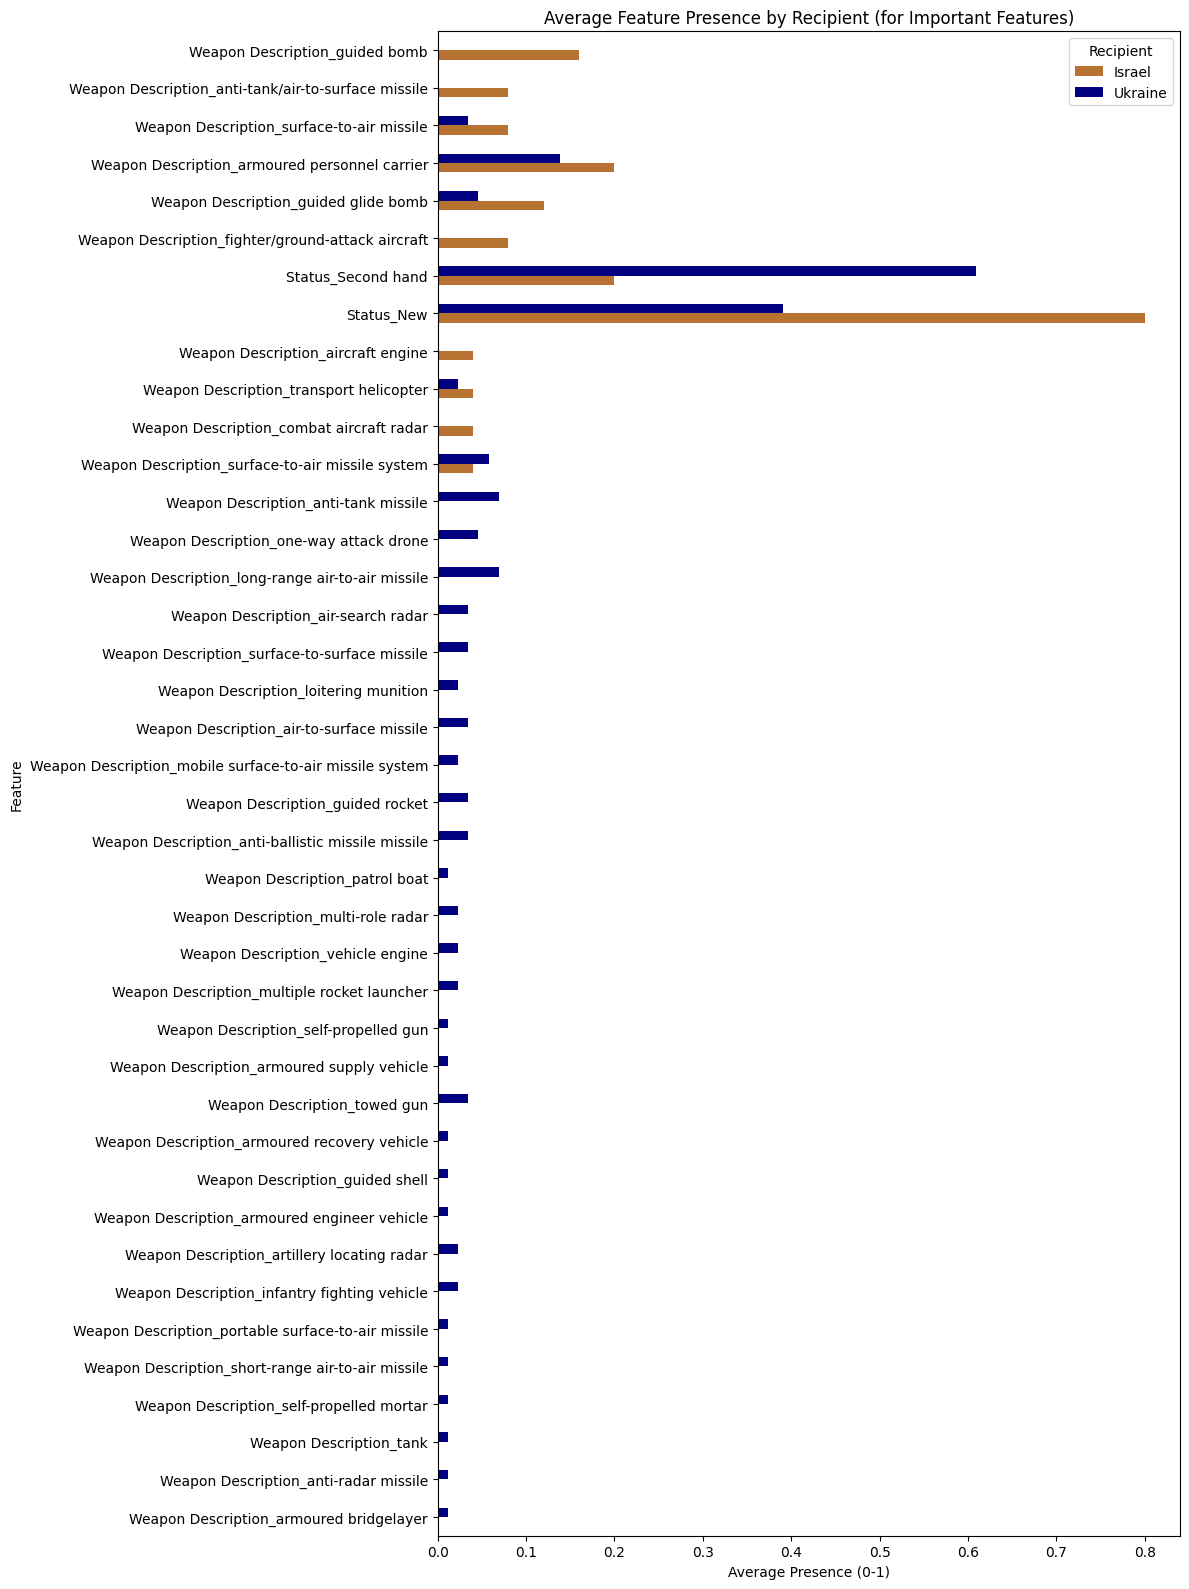

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare feature importances and filter out zero-importance features
feature_importance_series = pd.Series(importances, index=X.columns)

important_features = feature_importance_series[feature_importance_series > 0]
sorted_important_features = important_features.sort_values()

# Plot filtered feature importances
plt.figure(figsize=(12, max(6, len(sorted_important_features) * 0.4)))
plt.barh(sorted_important_features.index, sorted_important_features.values, color = 'maroon')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances (Non-Zero Importance)')
plt.tight_layout()
plt.show()

# see how important features lean towards Ukraine or Israel?
# Filter X to only include features that had importance
X_important = X[sorted_important_features.index]

# Add 'Recipient' column to X_important for grouping
X_important_with_labels = X_important.copy()
X_important_with_labels['Recipient'] = labels

# Calculate mean presence of each feature for each recipient
feature_presence_by_recipient = X_important_with_labels.groupby('Recipient').mean()

feature_presence_by_recipient_transposed = feature_presence_by_recipient.T

plt.figure(figsize=(12, max(6, len(sorted_important_features) * 0.4)))
feature_presence_by_recipient_transposed.plot(kind='barh', ax=plt.gca(), color=['#B87333', 'navy'])
plt.xlabel('Average Presence (0-1)')
plt.ylabel('Feature')
plt.title('Average Feature Presence by Recipient (for Important Features)')
plt.legend(title='Recipient')
plt.tight_layout()
plt.show()

Takeaways:

- random forest classifier worked better than KNN
  - RF was more generalizable
  - less/no overfitting
  - good accuracy (82%)



Next Steps:

- start to consolidate analysis
- explore more with feature importance (make a visual for RF model)
- cross compare feature importance with visuals made earlier
- continue lit review (focus on major events in each conflict) -- does this coincide with big changes in the visuals???
- start to consolidate this research again...

Day 8 to do -

- finish eval metrics for random forest model (done)
- create a bar plt for feature importance (done)
- create 2 line graphs showing US arms transfers to Ukraine and Israel throughout datasets entire timespan (done)
  - consider replicating the weapon distribution/status distribution over time --> this is not needed tho/will take a long time too (no)

- consolidate visuals and research points for final project

**- research major events in each conflict/cross examine current visuals (keep working on this!)**

- finish checkpoint three and submit...(done)

In [145]:
df.head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015.0,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005.0,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,NaN,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,NaN,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,NaN,New,0.40,16.4,16.4


In [150]:
us_ot = df[(df['Supplier'] == 'United States') & (df['Recipient'].isin(['Ukraine', 'Israel']))]

In [151]:
us_ot.describe()

,Year of Order,Number Ordered,Deliveries in the Year Range,Year(s) of delivery,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
count,396.000000,367.000000,379.000000,179.000000,396.000000,396.000000,396.000000
mean,1996.196970,508.419619,516.213720,1996.949721,6.991338,127.631717,113.628864
std,22.110461,2240.809122,2242.952327,21.805904,15.640750,297.256820,265.718864
min,1949.000000,1.000000,1.000000,1950.000000,0.000000,0.000000,0.000000
25%,1974.000000,10.000000,10.000000,1975.000000,0.100000,9.450000,10.000000
50%,1995.000000,44.000000,50.000000,1995.000000,0.570000,30.000000,30.000000
75%,2022.000000,210.000000,284.000000,2022.000000,4.460000,96.375000,90.000000
max,2025.000000,29500.000000,29500.000000,2025.000000,127.350000,2137.500000,2137.500000


In [156]:
us_ot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 396 entries, 3465 to 8908
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       396 non-null    object 
 1   Supplier                        396 non-null    object 
 2   Year of Order                   396 non-null    int64  
 3   Number Ordered                  367 non-null    float64
 4   Weapon Designation              396 non-null    object 
 5   Weapon Description              396 non-null    object 
 6   Deliveries in the Year Range    379 non-null    float64
 7   Year(s) of delivery             179 non-null    float64
 8   Status                          396 non-null    object 
 9   SIPRI TIV per unit              396 non-null    float64
 10  SIPRI TIV for total order       396 non-null    float64
 11  SIPRI TIV of delivered weapons  396 non-null    float64
dtypes: float64(6), int64(1), object(5)
me

In [153]:
df_US_Ukraine = us_ot[us_ot['Recipient'] == 'Ukraine']
US_Ukraine_data = df_US_Ukraine.groupby('Year of Order')['Deliveries in the Year Range'].sum()

df_US_Israel = us_ot[us_ot['Recipient'] == 'Israel']
US_Israel_data = df_US_Israel.groupby('Year of Order')['Deliveries in the Year Range'].sum()

In [161]:
US_Ukraine_data.describe()

,Deliveries in the Year Range
count,8.000000
mean,13864.125000
std,35461.380653
min,65.000000
25%,197.250000
50%,492.500000
75%,3347.250000
max,101511.000000


In [162]:
US_Israel_data.describe()

,Deliveries in the Year Range
count,67.000000
mean,1264.656716
std,1858.100395
min,0.000000
25%,84.500000
50%,418.000000
75%,1393.500000
max,7671.000000


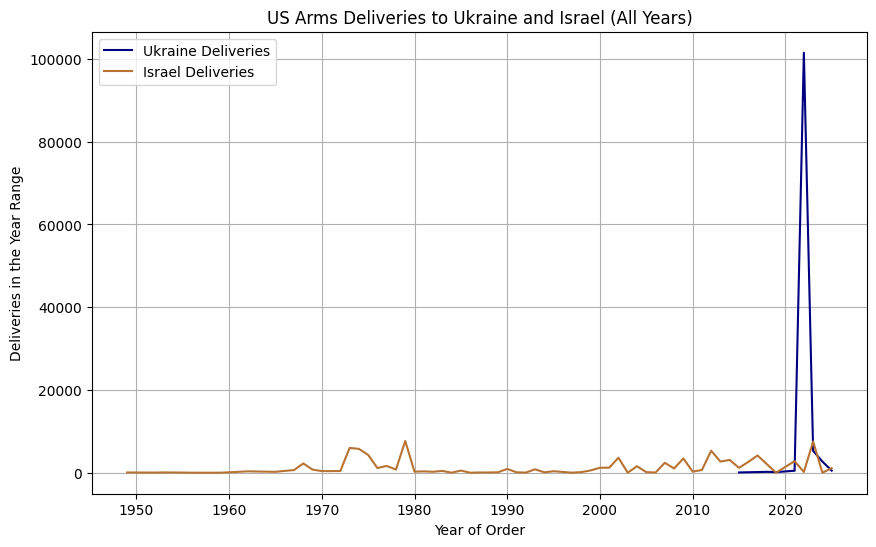

In [154]:
plt.figure(figsize=(10, 6))
plt.plot(US_Ukraine_data.index, US_Ukraine_data.values, label='Ukraine Deliveries', color='navy')
plt.plot(US_Israel_data.index, US_Israel_data.values, label='Israel Deliveries', color='#B87333')

plt.title('US Arms Deliveries to Ukraine and Israel (All Years)')
plt.xlabel('Year of Order')
plt.ylabel('Deliveries in the Year Range')
plt.legend()
plt.grid(True)
plt.show()